# Prediction - Delphin-Eye

Runs inference on new images using SAHI (Slicing Aided Hyper Inference).
SAHI tiles large images into 640×640 overlapping patches, runs detection on each,
then merges results - this preserves small fins that would vanish at full-image scale.

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

BEST_WEIGHTS = PROJECT_ROOT / "output" / "models" / "default" / "weights" / "best.pt"
IMAGES_DIR   = PROJECT_ROOT / "data" / "predict"
OUTPUT_DIR   = PROJECT_ROOT / "output" / "predictions"

CONFIDENCE   = 0.5   # raise if too many false positives, lower to catch more fins
SLICE_SIZE   = 640   # patch size fed to the model; must match training imgsz
OVERLAP      = 0.2   # overlap ratio between patches to avoid missing fins at edges

assert BEST_WEIGHTS.exists(), f"Model not found: {BEST_WEIGHTS}"
assert IMAGES_DIR.exists(),   f"Create the folder and add images: {IMAGES_DIR}"
print(f"Model : {BEST_WEIGHTS}")

Model : /home/corneille/Github/delphin-eye/output/models/default/weights/best.pt


In [3]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=str(BEST_WEIGHTS),
    confidence_threshold=CONFIDENCE,
    device="cpu",
)
print("Model loaded.")

Model loaded.


In [4]:
import shutil

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

image_paths = sorted(p for p in IMAGES_DIR.iterdir() if p.suffix in IMAGE_EXTENSIONS)
print(f"{len(image_paths)} images to process")

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)

for img_path in image_paths:
    result = get_sliced_prediction(
        str(img_path),
        detection_model,
        slice_height=SLICE_SIZE,
        slice_width=SLICE_SIZE,
        overlap_height_ratio=OVERLAP,
        overlap_width_ratio=OVERLAP,
    )
    result.export_visuals(export_dir=str(OUTPUT_DIR), file_name=img_path.stem)
    n = len(result.object_prediction_list)
    print(f"  {img_path.name}: {n} detection{'s' if n != 1 else ''}")

print(f"\nResults saved to: {OUTPUT_DIR}")

15 images to process
Performing prediction on 77 slices.
  0Z2A1194.JPG: 2 detections
Performing prediction on 77 slices.
  2A9A5575.JPG: 1 detection
Performing prediction on 77 slices.
  2A9A5580.JPG: 1 detection
Performing prediction on 77 slices.
  2A9A5590.JPG: 1 detection
Performing prediction on 77 slices.
  2A9A5591.JPG: 0 detections
Performing prediction on 77 slices.
  2A9A5592.JPG: 0 detections
Performing prediction on 77 slices.
  2A9A5593.JPG: 1 detection
Performing prediction on 77 slices.
  2A9A5594.JPG: 0 detections
Performing prediction on 77 slices.
  2A9A5595.JPG: 0 detections
Performing prediction on 77 slices.
  2A9A5596.JPG: 0 detections
Performing prediction on 77 slices.
  2A9A5597.JPG: 1 detection
Performing prediction on 77 slices.
  2A9A5598.JPG: 0 detections
Performing prediction on 77 slices.
  2A9A5599.JPG: 0 detections
Performing prediction on 77 slices.
  2A9A5600.JPG: 0 detections
Performing prediction on 77 slices.
  2A9A5601.JPG: 1 detection

Results s

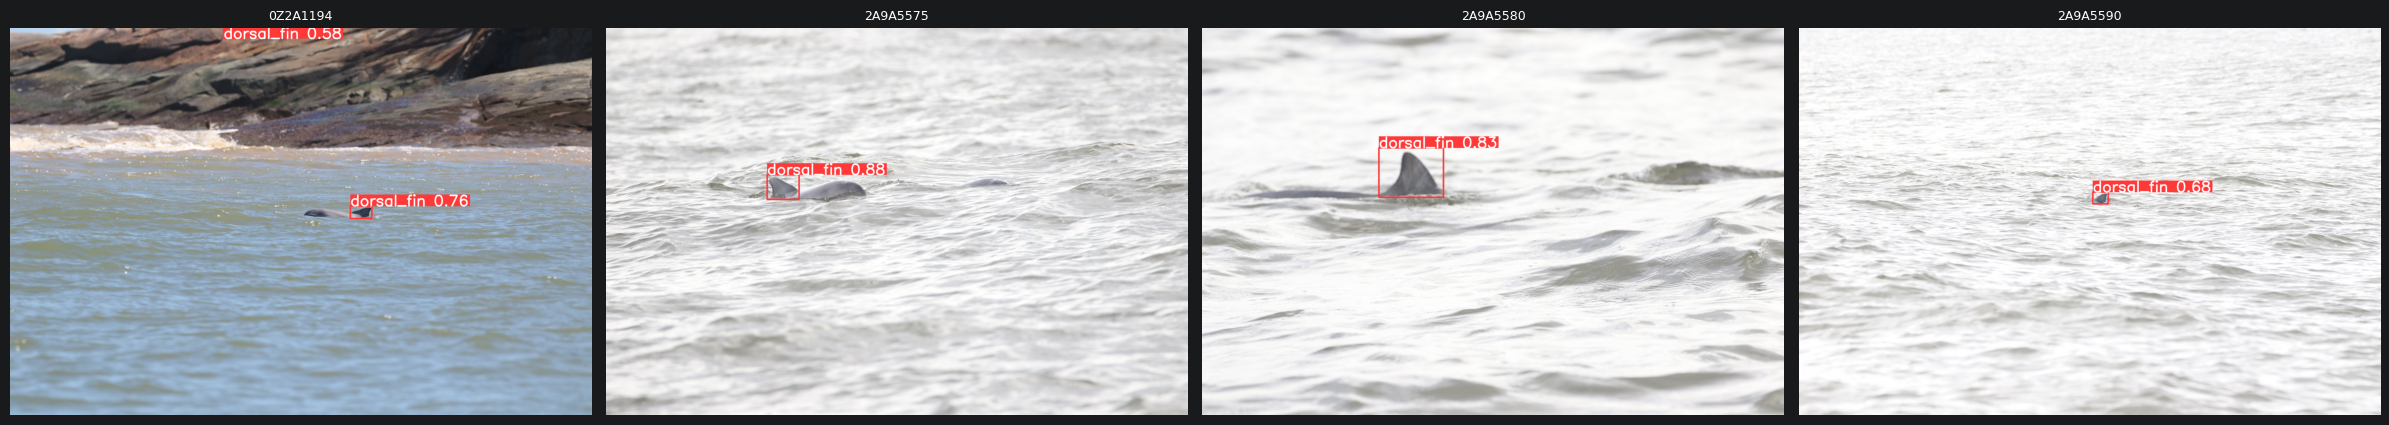

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pred_images = sorted(OUTPUT_DIR.glob("*.png"))[:4]

if not pred_images:
    print(f"No output images found in {OUTPUT_DIR}")
else:
    fig, axes = plt.subplots(1, len(pred_images), figsize=(6 * len(pred_images), 6))
    if len(pred_images) == 1:
        axes = [axes]
    for ax, img_path in zip(axes, pred_images):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(img_path.stem, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()